# Steam Recommendation System — Mini-project 2

**Dataset:** Steam Review and Bundle Dataset (Australian user subset)
**Model:** NeuMF (Neural Matrix Factorization) — He et al., 2017

| File | Description |
|---|---|
| `australian_user_reviews.json.gz` | User reviews with binary `recommend` signal |
| `australian_users_items.json.gz` | Games owned by users + playtime (minutes) |
| `steam_games.json.gz` | Game metadata: genres, tags, price, publisher, release date |

We ignore `bundle_data.json.gz` and `steam_reviews.json.gz`: bundles are not used by the model, and the aggregated `steam_reviews` cover a different population from the Australian users in the interaction data.

---

## Table of Contents

1. Setup & Data Download
2. Data Loading
3. Dataset Overview
4. Exploratory Data Analysis
5. Data Preparation for Modeling
6. NeuMF Model Architecture
7. Training & Iterative Justification
8. Evaluation & Ablation Study


---
## 1. Setup & Data Download

In [1]:
import os

DATA_DIR = "./steam-review-and-bundle-dataset"

if not os.path.exists(DATA_DIR):
    !git clone https://huggingface.co/datasets/recommender-system/steam-review-and-bundle-dataset
else:
    !cd {DATA_DIR} && git pull

Already up to date.


In [2]:
import sys
sys.path.insert(0, "..")

import re
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pathlib import Path
from scipy import stats as scipy_stats
from sklearn.preprocessing import StandardScaler

from project2.dataset import load_all_datasets, parse_price
from project2.plots import (
    set_style,
    plot_recommend_distribution,
    plot_reviews_per_user, plot_items_per_user,
    plot_reviews_per_item, plot_top_reviewed_games, plot_top_played_games,
    plot_playtime_distribution, plot_playtime_vs_recommend,
    plot_genre_distribution, plot_top_tags, plot_price_distribution,
    plot_release_year_distribution, plot_early_access_distribution,
    plot_reviews_over_time,
    plot_sparsity,
)

set_style()
DATA_PATH = Path(DATA_DIR)
print("Imports OK")

2026-04-18 12:36:52.215 | INFO     | project2.config:<module>:7 - PROJ_ROOT path is: /home/ptomco/School/5-year/LS/ISA/ISA_movielens_recsys


Imports OK


 ---
## 2. Data Loading

In [ ]:
df_reviews, df_items, df_games = load_all_datasets(DATA_PATH)
print("Datasets loaded.")

---
## 3. Dataset Overview

Before diving into analysis, we get a high-level summary of every dataset: shape, unique users/items, and missing values.

In [68]:
df_reviews.head()

,user_id,item_id,recommend,review,posted,helpful,funny
0,76561197970982479,1250,True,Simple yet with great replayability. In my opi...,"Posted November 5, 2011.",No ratings yet,
1,76561197970982479,22200,True,It's unique and worth a playthrough.,"Posted July 15, 2011.",No ratings yet,
2,76561197970982479,43110,True,Great atmosphere. The gunplay can be a bit chu...,"Posted April 21, 2011.",No ratings yet,
3,js41637,251610,True,I know what you think when you see this title ...,"Posted June 24, 2014.",15 of 20 people (75%) found this review helpful,
4,js41637,227300,True,For a simple (it's actually not all that simpl...,"Posted September 8, 2013.",0 of 1 people (0%) found this review helpful,


In [33]:
df_items.head()

,user_id,item_id,item_name,playtime_forever,playtime_2weeks
0,76561197970982479,10,Counter-Strike,6,0
1,76561197970982479,20,Team Fortress Classic,0,0
2,76561197970982479,30,Day of Defeat,7,0
3,76561197970982479,40,Deathmatch Classic,0,0
4,76561197970982479,50,Half-Life: Opposing Force,0,0


In [89]:
df_games.head()

,publisher,genres,app_name,title,url,release_date,tags,discount_price,reviews_url,specs,price,early_access,id,developer,sentiment,metascore,price_numeric
0,Kotoshiro,"[Action, Casual, Indie, Simulation, Strategy]",Lost Summoner Kitty,Lost Summoner Kitty,http://store.steampowered.com/app/761140/Lost_...,2018-01-04,"[Strategy, Action, Indie, Casual, Simulation]",4.49,http://steamcommunity.com/app/761140/reviews/?...,[Single-player],4.99,False,761140,Kotoshiro,NaN,NaN,4.99
1,"Making Fun, Inc.","[Free to Play, Indie, RPG, Strategy]",Ironbound,Ironbound,http://store.steampowered.com/app/643980/Ironb...,2018-01-04,"[Free to Play, Strategy, Indie, RPG, Card Game...",NaN,http://steamcommunity.com/app/643980/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free To Play,False,643980,Secret Level SRL,Mostly Positive,NaN,0.00
2,Poolians.com,"[Casual, Free to Play, Indie, Simulation, Sports]",Real Pool 3D - Poolians,Real Pool 3D - Poolians,http://store.steampowered.com/app/670290/Real_...,2017-07-24,"[Free to Play, Simulation, Sports, Casual, Ind...",NaN,http://steamcommunity.com/app/670290/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free to Play,False,670290,Poolians.com,Mostly Positive,NaN,0.00
3,彼岸领域,"[Action, Adventure, Casual]",弹炸人2222,弹炸人2222,http://store.steampowered.com/app/767400/2222/,2017-12-07,"[Action, Adventure, Casual]",0.83,http://steamcommunity.com/app/767400/reviews/?...,[Single-player],0.99,False,767400,彼岸领域,NaN,NaN,0.99
4,NaN,None,Log Challenge,NaN,http://store.steampowered.com/app/773570/Log_C...,NaN,"[Action, Indie, Casual, Sports]",1.79,http://steamcommunity.com/app/773570/reviews/?...,"[Single-player, Full controller support, HTC V...",2.99,False,773570,NaN,NaN,NaN,2.99


---
## 4. Exploratory Data Analysis

We cover the basics: dataset shapes, missing values, duplicates, outliers, distributions, the target, game metadata, sparsity, and feature-target correlations. The goal is to understand the data before modeling, not to catalogue every attribute.

### Dataset Overview

In [69]:
# Shape and unique-identifier counts for the three datasets we keep.
DATASETS = {
    "df_reviews": df_reviews,
    "df_items":   df_items,
    "df_games":   df_games,
}

summary_rows = []
for name, df in DATASETS.items():
    row = {"dataset": name, "rows": len(df), "cols": len(df.columns)}
    for col in ("user_id", "item_id", "id"):
        if col in df.columns:
            try:
                row[f"unique_{col}"] = df[col].nunique()
            except TypeError:
                pass
    summary_rows.append(row)

display(pd.DataFrame(summary_rows).fillna("-"))

,dataset,rows,cols,unique_user_id,unique_item_id,unique_id
0,df_reviews,59305,7,25458.0,3682.0,-
1,df_items,5153209,5,70912.0,10978.0,-
2,df_games,32135,17,-,-,32132.0


### Data Preprocessing

Parse list-type columns, dates, vote strings, and playtime so the rest of EDA can work with clean types.

In [70]:
# Produce clean copies with parsed dates, votes, playtime transforms, and list columns.
import ast

df_rev = df_reviews.copy()
df_itm = df_items.copy()
df_gm  = df_games.copy()


def _to_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, str) and x.strip() not in ("", "nan", "None"):
        try:
            v = ast.literal_eval(x)
            return v if isinstance(v, list) else []
        except (ValueError, SyntaxError):
            return []
    return []


def _parse_posted(s):
    if not isinstance(s, str) or s.strip() in ("", "nan"):
        return pd.NaT
    s = re.sub(r"^Posted\s+", "", s.strip().rstrip("."))
    return pd.to_datetime(s, format="%B %d, %Y", errors="coerce")


for col in ("genres", "tags", "specs"):
    df_gm[col] = df_gm[col].apply(_to_list)

df_rev["posted_date"]   = df_rev["posted"].apply(_parse_posted)
df_rev["helpful_votes"] = df_rev["helpful"].astype(str).str.extract(r"(\d+)").fillna(0).astype(int)
df_rev["review_len"]    = df_rev["review"].astype(str).str.len()

df_itm["playtime_log1p"] = np.log1p(df_itm["playtime_forever"])

df_gm["release_year"] = pd.to_datetime(df_gm["release_date"], errors="coerce").dt.year
df_gm["is_free"]      = df_gm["price_numeric"] == 0

print(f"Posted dates parsed:  {df_rev['posted_date'].notna().mean() * 100:5.1f}%")
print(f"Max helpful votes:    {df_rev['helpful_votes'].max():,}")
print(f"Max playtime (hours): {df_itm['playtime_forever'].max() / 60:,.0f}")
print(f"Release year range:   {int(df_gm['release_year'].min())}-{int(df_gm['release_year'].max())}")

Posted dates parsed:   82.9%
Max helpful votes:    981
Max playtime (hours): 10,713
Release year range:   1970-2021


### Missing Values

Count how many values are missing in each column and visualize where the nulls sit.

,dataset,column,null_count,null_pct
0,df_games,discount_price,31910,99.30
1,df_games,metascore,29458,91.67
2,df_games,publisher,8052,25.06
3,df_games,sentiment,7182,22.35
4,df_games,developer,3299,10.27
5,df_games,genres,3283,10.22
6,df_games,release_date,2067,6.43
7,df_games,title,2050,6.38
8,df_games,price_numeric,1400,4.36
9,df_games,price,1377,4.29


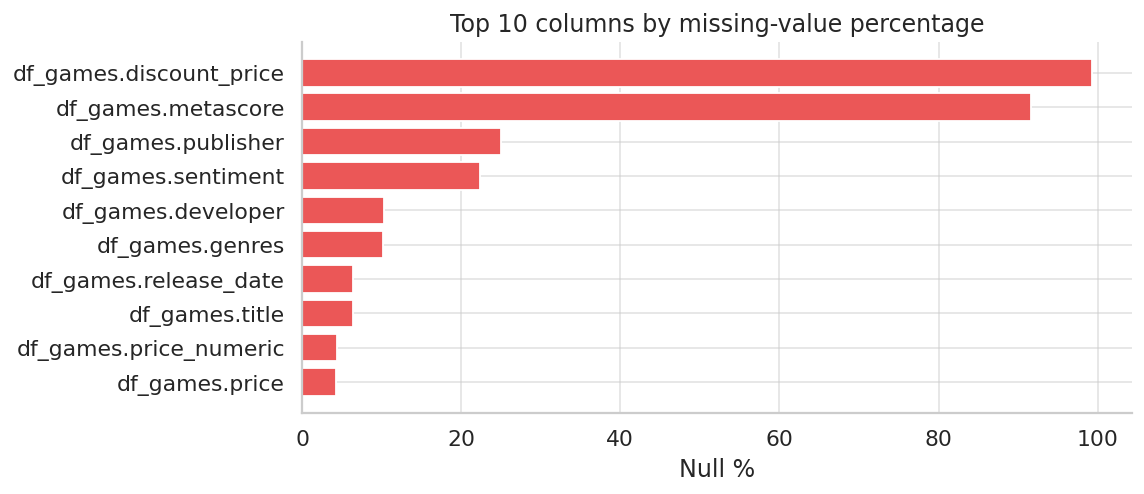

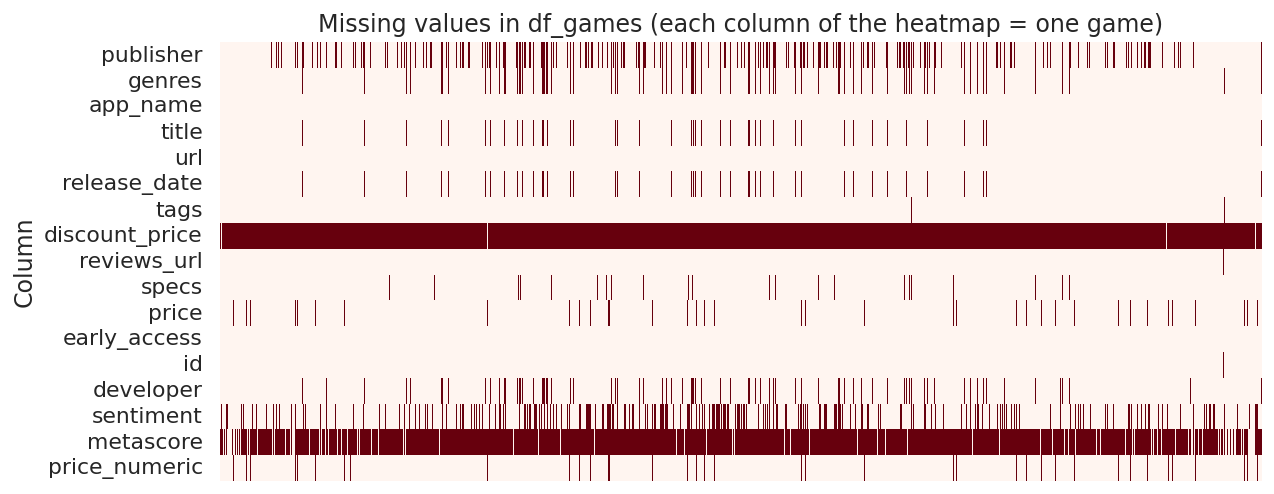

In [71]:
# Count nulls per column and show both a ranked table and a per-column heatmap for df_games.
missing_rows = []
for name, df in DATASETS.items():
    for col in df.columns:
        n = int(df[col].isnull().sum())
        if n > 0:
            missing_rows.append({
                "dataset":    name,
                "column":     col,
                "null_count": n,
                "null_pct":   round(n / len(df) * 100, 2),
            })

missing_df = pd.DataFrame(missing_rows).sort_values("null_pct", ascending=False).reset_index(drop=True)
display(missing_df.head(15))

fig, ax = plt.subplots(figsize=(9, 4))
top = missing_df.head(10)
ax.barh(top["dataset"] + "." + top["column"], top["null_pct"], color="#EB5757")
ax.invert_yaxis()
ax.set_xlabel("Null %")
ax.set_title("Top 10 columns by missing-value percentage")
plt.tight_layout()
plt.show()

# Per-row heatmap for df_games -- shows which columns tend to be missing together.
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_games.isnull().astype(int).T, cbar=False, cmap="Reds",
            ax=ax, xticklabels=False, linewidths=0)
ax.set_title("Missing values in df_games (each column of the heatmap = one game)")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

### Duplicates

Look for full duplicate rows and repeated primary keys.

In [72]:
# Count exact duplicate rows and duplicate primary keys per dataset.
def _hashable_cols(df):
    out = []
    for c in df.columns:
        sample = df[c].dropna().iloc[0] if df[c].notna().any() else None
        if not isinstance(sample, (list, np.ndarray)):
            out.append(c)
    return out


dup_specs = [
    ("df_reviews", df_reviews, ["user_id", "item_id"]),
    ("df_items",   df_items,   ["user_id", "item_id"]),
    ("df_games",   df_games,   ["id"]),
]

dup_rows = []
for name, df, keys in dup_specs:
    hc = _hashable_cols(df)
    full_dup = int(df.duplicated(subset=hc).sum()) if hc else 0
    key_dup  = int(df.duplicated(subset=keys).sum()) if keys else 0
    dup_rows.append({"dataset": name, "rows": len(df),
                     "full_dup_rows": full_dup, "dup_key_rows": key_dup})

display(pd.DataFrame(dup_rows))
print("Duplicates are dropped downstream by build_interaction_table (see section 5).")

,dataset,rows,full_dup_rows,dup_key_rows
0,df_reviews,59305,874,874
1,df_items,5153209,59104,59127
2,df_games,32135,0,2


Duplicates are dropped downstream by build_interaction_table (see section 5).


### Outlier Detection

Use the IQR rule to check the right tails of the main numeric columns.

,column,Q1,Q3,lower_fence,upper_fence,n_outliers,pct
0,playtime_forever (>0),44.0,808.0,-1102.0,1954.0,436754,13.29
1,helpful_votes,0.0,1.0,-1.5,2.5,7055,11.90
2,review_len,30.0,207.0,-235.5,472.5,6484,10.93
3,price,3.0,10.0,-7.5,20.5,1883,6.13


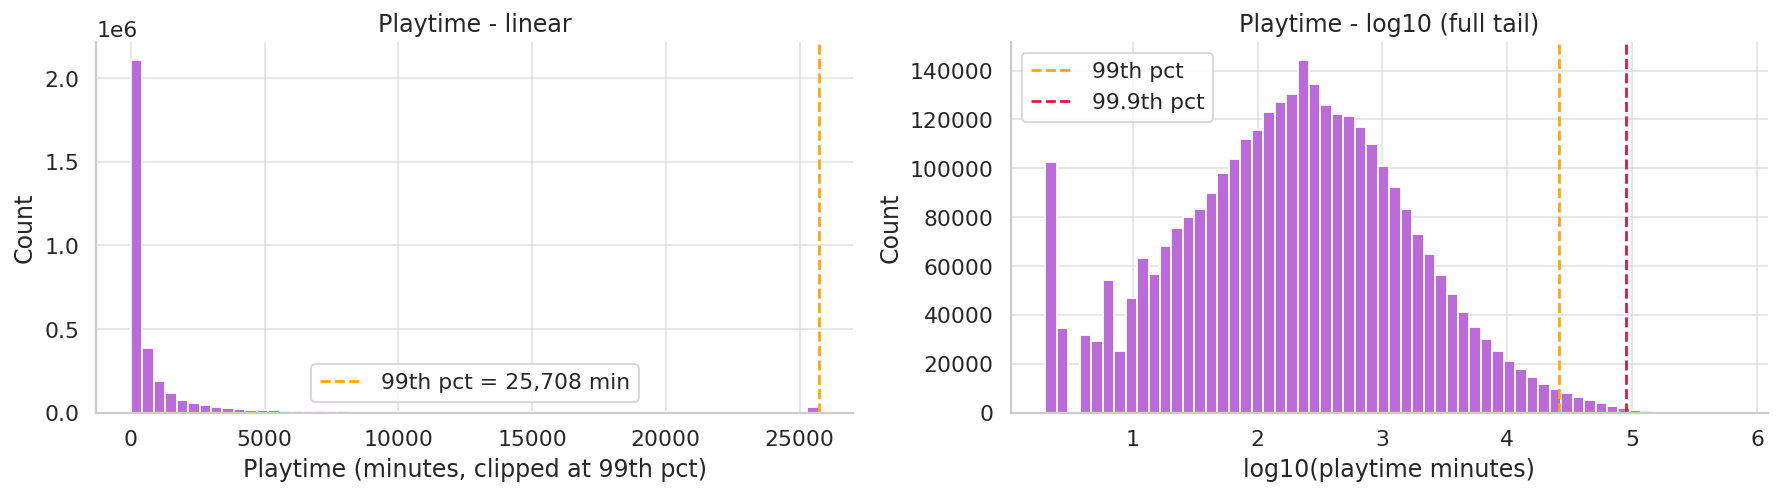

We keep these outliers: they reflect real power-user behaviour.
For scale-sensitive use we rely on log1p(playtime), already stored in df_itm['playtime_log1p'].


In [93]:
# Flag outliers via the 1.5*IQR rule and visualize the playtime tail (linear + log).
def iqr_outliers(series, name):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lo) | (s > hi)
    return {
        "column":       name,
        "Q1":           round(q1, 1),
        "Q3":           round(q3, 1),
        "lower_fence":  round(lo, 1),
        "upper_fence":  round(hi, 1),
        "n_outliers":   int(mask.sum()),
        "pct":          round(mask.mean() * 100, 2),
    }


outlier_df = pd.DataFrame([
    iqr_outliers(df_itm.loc[df_itm["playtime_forever"] > 0, "playtime_forever"], "playtime_forever (>0)"),
    iqr_outliers(df_rev["helpful_votes"],                                        "helpful_votes"),
    iqr_outliers(df_rev["review_len"],                                           "review_len"),
    iqr_outliers(df_gm.loc[df_gm["price_numeric"].notna(), "price_numeric"],     "price"),
])
display(outlier_df)

played = df_itm.loc[df_itm["playtime_forever"] > 0, "playtime_forever"]
p99  = played.quantile(0.99)
p999 = played.quantile(0.999)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Linear scale -- clipped at the 99th percentile so the readable range is visible.
axes[0].hist(played.clip(upper=p99), bins=60, color="#BB6BD9", edgecolor="white")
axes[0].axvline(p99, color="orange", linestyle="--", label=f"99th pct = {p99:,.0f} min")
axes[0].set_xlabel("Playtime (minutes, clipped at 99th pct)")
axes[0].set_ylabel("Count")
axes[0].set_title("Playtime - linear")
axes[0].legend()

# Log10 scale -- shows the full tail including the power users.
axes[1].hist(np.log10(played + 1), bins=60, color="#BB6BD9", edgecolor="white")
axes[1].axvline(np.log10(p99  + 1), color="orange",  linestyle="--", label="99th pct")
axes[1].axvline(np.log10(p999 + 1), color="crimson", linestyle="--", label="99.9th pct")
axes[1].set_xlabel("log10(playtime minutes)")
axes[1].set_ylabel("Count")
axes[1].set_title("Playtime - log10 (full tail)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("We keep these outliers: they reflect real power-user behaviour.")
print("For scale-sensitive use we rely on log1p(playtime), already stored in df_itm['playtime_log1p'].")

### Activity Distributions

One plot per variable so each is easier to read.

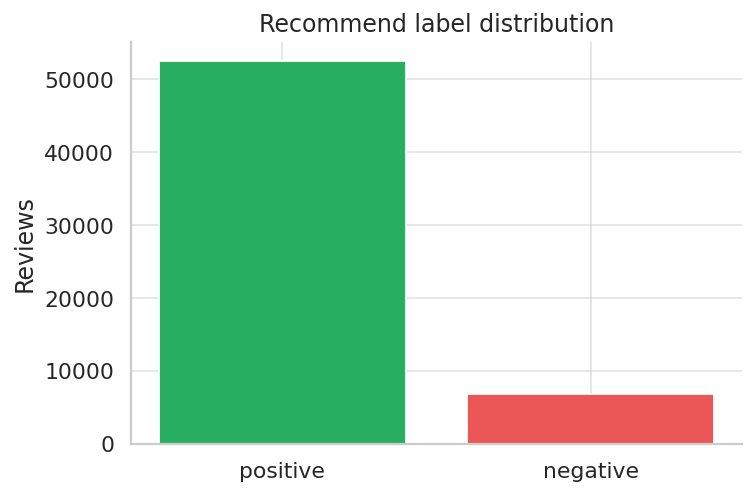

In [91]:
# Positive vs negative recommend split.
fig, ax = plt.subplots(figsize=(6, 4))
rec_counts = df_rev["recommend"].value_counts()
ax.bar(["positive", "negative"],
       [int(rec_counts.get(True, 0)), int(rec_counts.get(False, 0))],
       color=["#27AE60", "#EB5757"])
ax.set_ylabel("Reviews")
ax.set_title("Recommend label distribution")
plt.tight_layout()
plt.show()

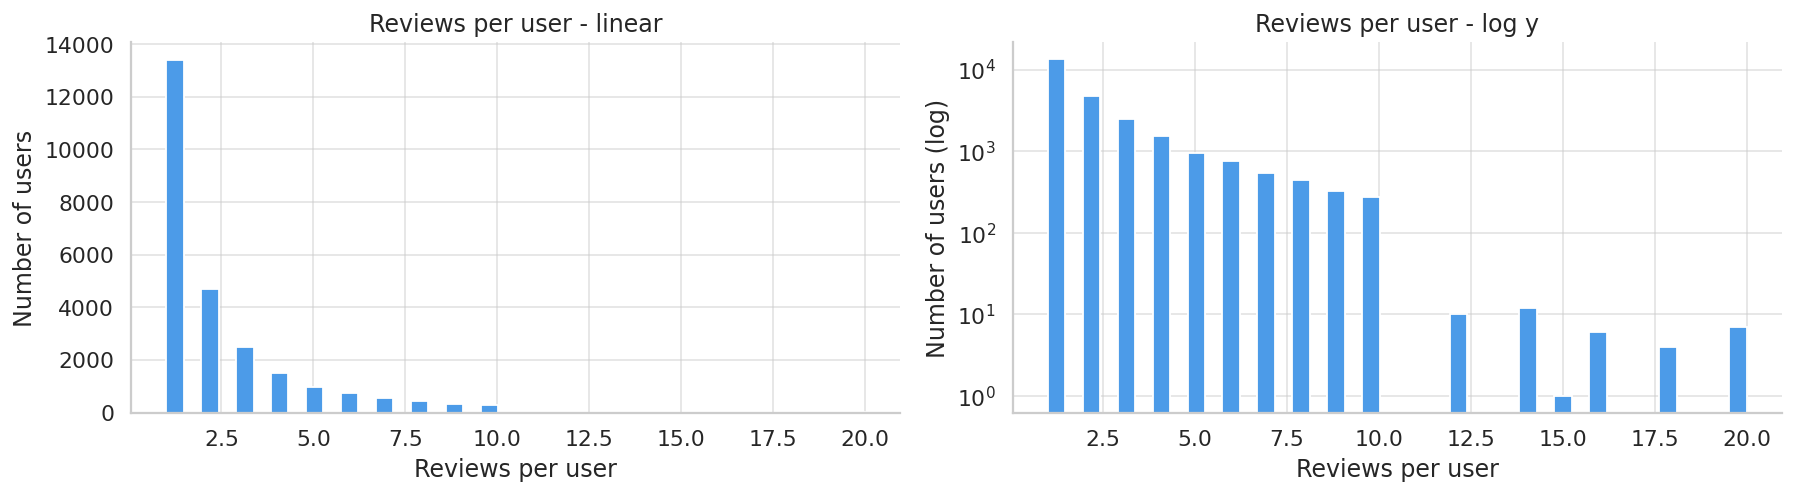

In [94]:
# Reviews per user -- linear (readable range) and log (full tail) side by side.
reviews_per_user = df_rev.groupby("user_id").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(reviews_per_user, bins=40, color="#4C9BE8", edgecolor="white")
axes[0].set_xlabel("Reviews per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Reviews per user - linear")

axes[1].hist(reviews_per_user, bins=40, log=True, color="#4C9BE8", edgecolor="white")
axes[1].set_xlabel("Reviews per user")
axes[1].set_ylabel("Number of users (log)")
axes[1].set_title("Reviews per user - log y")

plt.tight_layout()
plt.show()

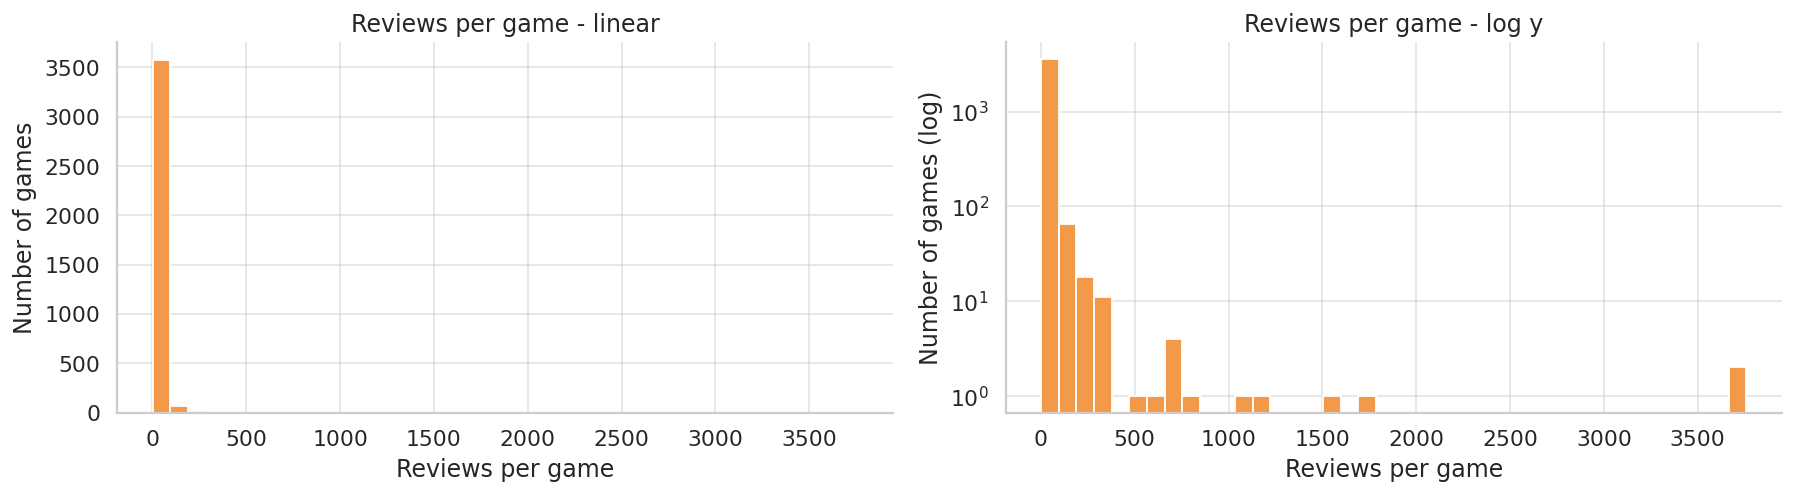

In [95]:
# Reviews per game -- linear (readable range) and log (full tail) side by side.
reviews_per_game = df_rev.groupby("item_id").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(reviews_per_game, bins=40, color="#F2994A", edgecolor="white")
axes[0].set_xlabel("Reviews per game")
axes[0].set_ylabel("Number of games")
axes[0].set_title("Reviews per game - linear")

axes[1].hist(reviews_per_game, bins=40, log=True, color="#F2994A", edgecolor="white")
axes[1].set_xlabel("Reviews per game")
axes[1].set_ylabel("Number of games (log)")
axes[1].set_title("Reviews per game - log y")

plt.tight_layout()
plt.show()

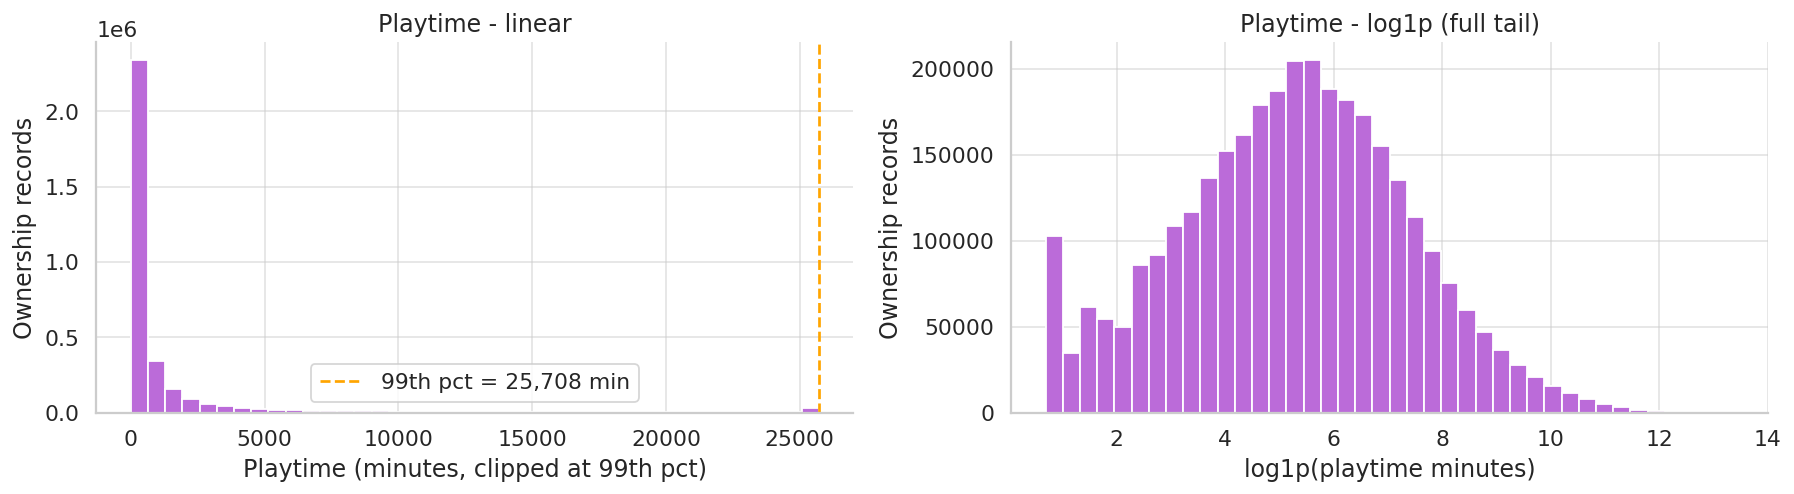

In [96]:
# Playtime distribution -- linear minutes (readable) vs log1p (full tail), players with >0 minutes.
played_min   = df_itm.loc[df_itm["playtime_forever"] > 0, "playtime_forever"]
played_log1p = df_itm.loc[df_itm["playtime_forever"] > 0, "playtime_log1p"]
p99 = played_min.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(played_min.clip(upper=p99), bins=40, color="#BB6BD9", edgecolor="white")
axes[0].axvline(p99, color="orange", linestyle="--", label=f"99th pct = {p99:,.0f} min")
axes[0].set_xlabel("Playtime (minutes, clipped at 99th pct)")
axes[0].set_ylabel("Ownership records")
axes[0].set_title("Playtime - linear")
axes[0].legend()

axes[1].hist(played_log1p, bins=40, color="#BB6BD9", edgecolor="white")
axes[1].set_xlabel("log1p(playtime minutes)")
axes[1].set_ylabel("Ownership records")
axes[1].set_title("Playtime - log1p (full tail)")

plt.tight_layout()
plt.show()

### Game Metadata Features

These features describe *games* rather than interactions and will feed the item embeddings (multi-hot genre vectors plus optional side features).

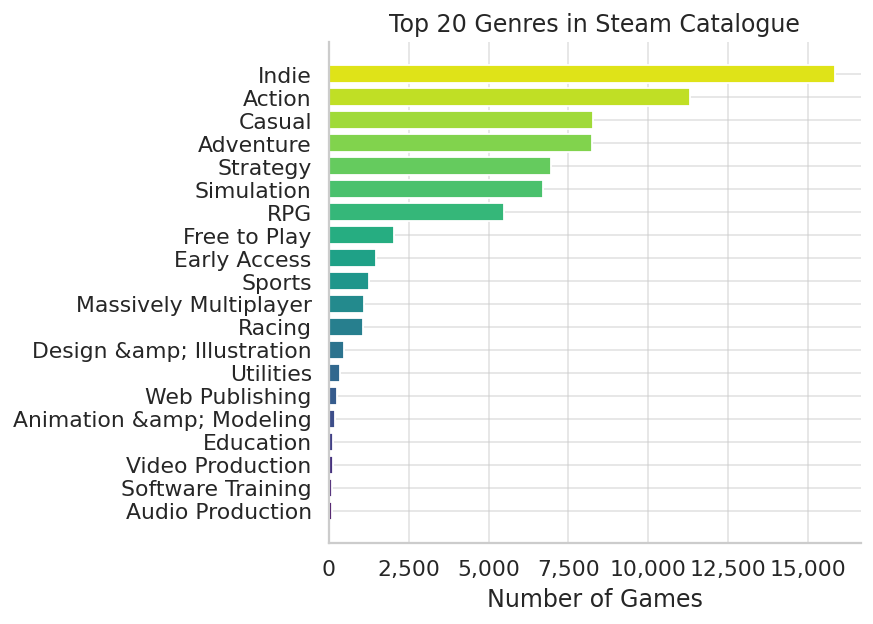

In [97]:
# Top 20 genres across the Steam catalogue.
plot_genre_distribution(df_gm, n=20)
plt.tight_layout()
plt.show()

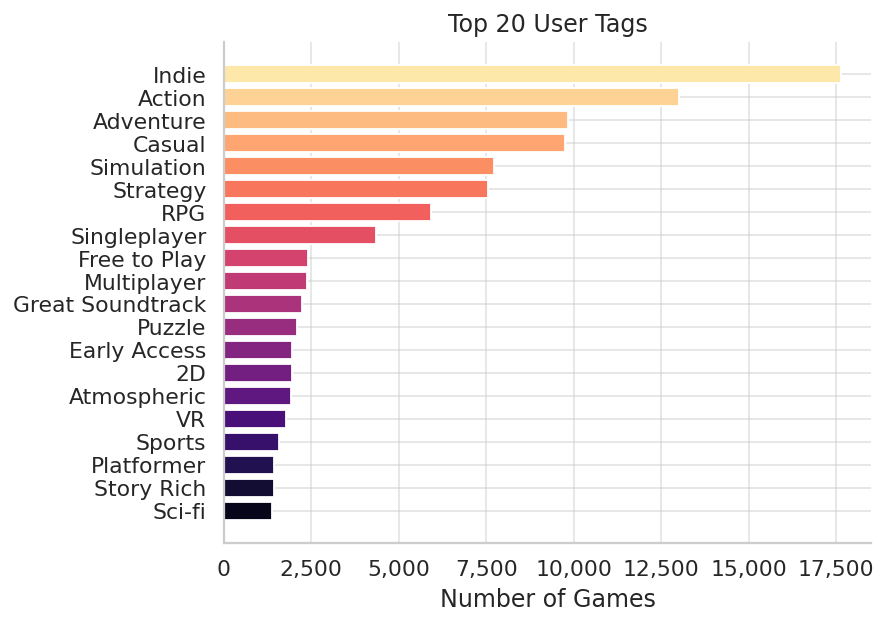

In [98]:
# Top 20 user-assigned tags -- more fine-grained than genres.
plot_top_tags(df_gm, n=20)
plt.tight_layout()
plt.show()

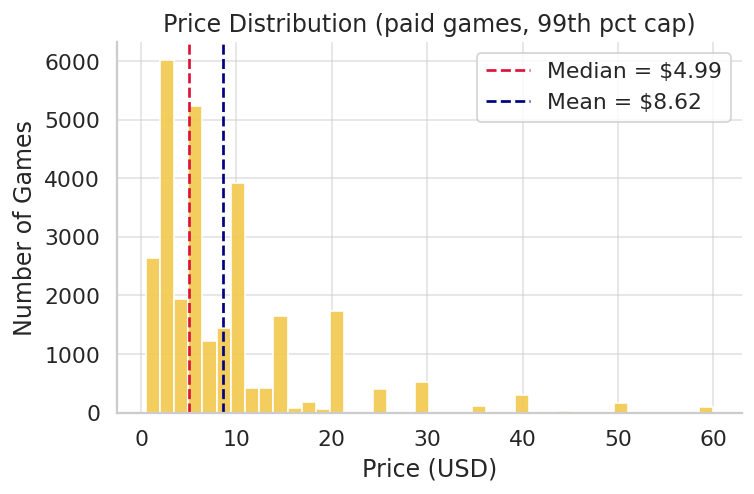

In [99]:
# Price distribution of paid games (free-to-play excluded by the helper).
plot_price_distribution(df_gm)
plt.tight_layout()
plt.show()

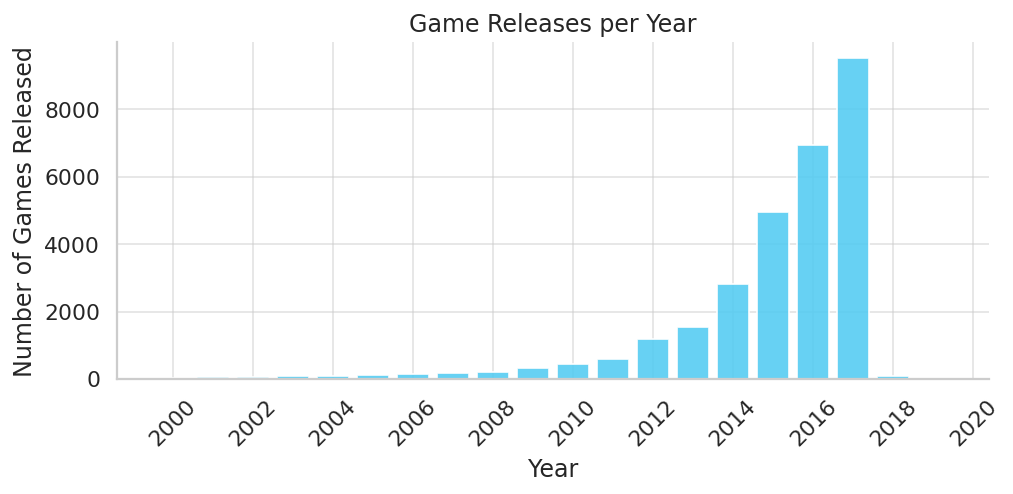

In [100]:
# Number of game releases per year -- shows catalogue growth over time.
plot_release_year_distribution(df_gm)
plt.tight_layout()
plt.show()

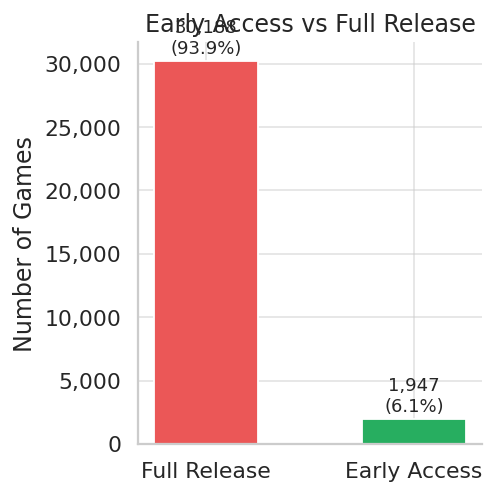

In [101]:
# Early-access vs fully-released games.
plot_early_access_distribution(df_gm)
plt.tight_layout()
plt.show()

### Target Variable Analysis

`recommend` is heavily imbalanced: most reviews are positive.

Positive: 52,473 (88.5%)
Negative: 6,832 (11.5%)
Users who always recommend: 20,440 (80.3%)
Users who never  recommend: 1,334 (5.2%)


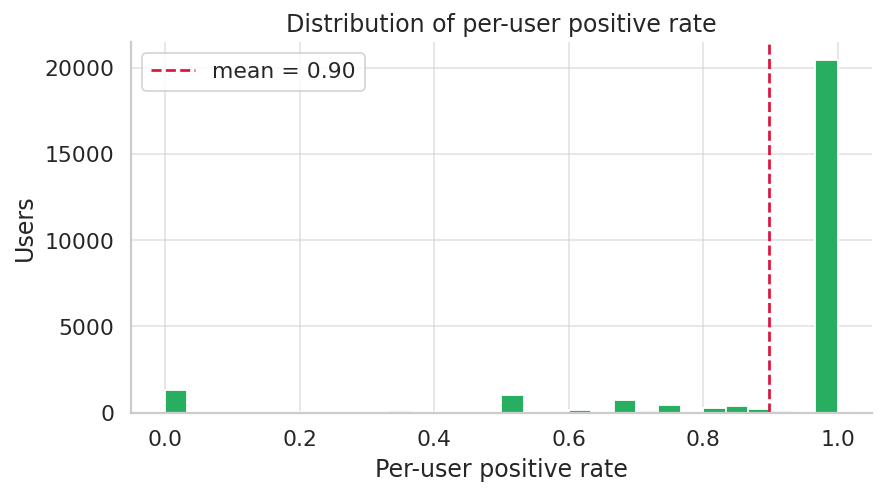

In [102]:
# Split of positive vs negative recommendations + per-user tendency to recommend.
pos = int(df_rev["recommend"].sum())
neg = int((~df_rev["recommend"]).sum())
print(f"Positive: {pos:,} ({pos / len(df_rev) * 100:.1f}%)")
print(f"Negative: {neg:,} ({neg / len(df_rev) * 100:.1f}%)")

user_pos = df_rev.groupby("user_id")["recommend"].mean()
pure_pos = int((user_pos == 1.0).sum())
pure_neg = int((user_pos == 0.0).sum())
print(f"Users who always recommend: {pure_pos:,} ({pure_pos / len(user_pos) * 100:.1f}%)")
print(f"Users who never  recommend: {pure_neg:,} ({pure_neg / len(user_pos) * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(user_pos, bins=30, color="#27AE60", edgecolor="white")
ax.axvline(user_pos.mean(), color="crimson", linestyle="--",
           label=f"mean = {user_pos.mean():.2f}")
ax.set_xlabel("Per-user positive rate")
ax.set_ylabel("Users")
ax.set_title("Distribution of per-user positive rate")
ax.legend()
plt.tight_layout()
plt.show()

### Cold-start and Sparsity

How many users / items survive the minimum-interaction filter, and how sparse the resulting matrix is.

In [103]:
# Compare raw counts with what survives the >=5 / >=10 review thresholds.
user_counts = df_rev.groupby("user_id").size()
item_counts = df_rev.groupby("item_id").size()

active_users  = int((user_counts >= 5).sum())
popular_items = int((item_counts >= 10).sum())

filter_df = pd.DataFrame([
    {"entity": "users", "total": len(user_counts),
     "kept": active_users,  "dropped": len(user_counts) - active_users,
     "threshold": ">= 5 reviews"},
    {"entity": "items", "total": len(item_counts),
     "kept": popular_items, "dropped": len(item_counts) - popular_items,
     "threshold": ">= 10 reviews"},
])
display(filter_df)

density = len(df_rev) / (len(user_counts) * len(item_counts))
print(f"Raw review matrix: {len(user_counts):,} users x {len(item_counts):,} items  "
      f"-> {density * 100:.4f}% dense ({(1 - density) * 100:.4f}% sparse)")
print("After filtering we keep a small dense core (~1.2K users x ~211 games) -- see section 5.")

,entity,total,kept,dropped,threshold
0,users,25458,3334,22124,>= 5 reviews
1,items,3682,715,2967,>= 10 reviews


Raw review matrix: 25,458 users x 3,682 items  -> 0.0633% dense (99.9367% sparse)
After filtering we keep a small dense core (~1.2K users x ~211 games) -- see section 5.


### Feature-Target Correlations

Point-biserial correlation between a few numeric features and the binary `recommend` label.

In [104]:
# Point-biserial correlation of numeric signals against the recommend label.
from scipy.stats import pointbiserialr

play_m = df_rev.merge(
    df_itm[["user_id", "item_id", "playtime_forever"]],
    on=["user_id", "item_id"], how="left",
)
play_m["log_play"] = np.log1p(play_m["playtime_forever"].fillna(0))

feat_specs = [
    ("log(playtime+1)", play_m["log_play"],      play_m["recommend"].astype(int)),
    ("review_len",      df_rev["review_len"],    df_rev["recommend"].astype(int)),
    ("helpful_votes",   df_rev["helpful_votes"], df_rev["recommend"].astype(int)),
]

rows = []
for name, x, y in feat_specs:
    r, p = pointbiserialr(y, x)
    rows.append({"feature": name, "r": round(r, 4), "p_value": f"{p:.2e}"})

display(pd.DataFrame(rows))
print("Playtime is the strongest continuous signal; review length and helpful votes carry little.")

,feature,r,p_value
0,log(playtime+1),0.1029,1.42e-142
1,review_len,-0.0659,4.32e-58
2,helpful_votes,-0.0536,5.59e-39


Playtime is the strongest continuous signal; review length and helpful votes carry little.


### Correlation Matrix

Pearson correlation across the main numeric features (review side and game side).

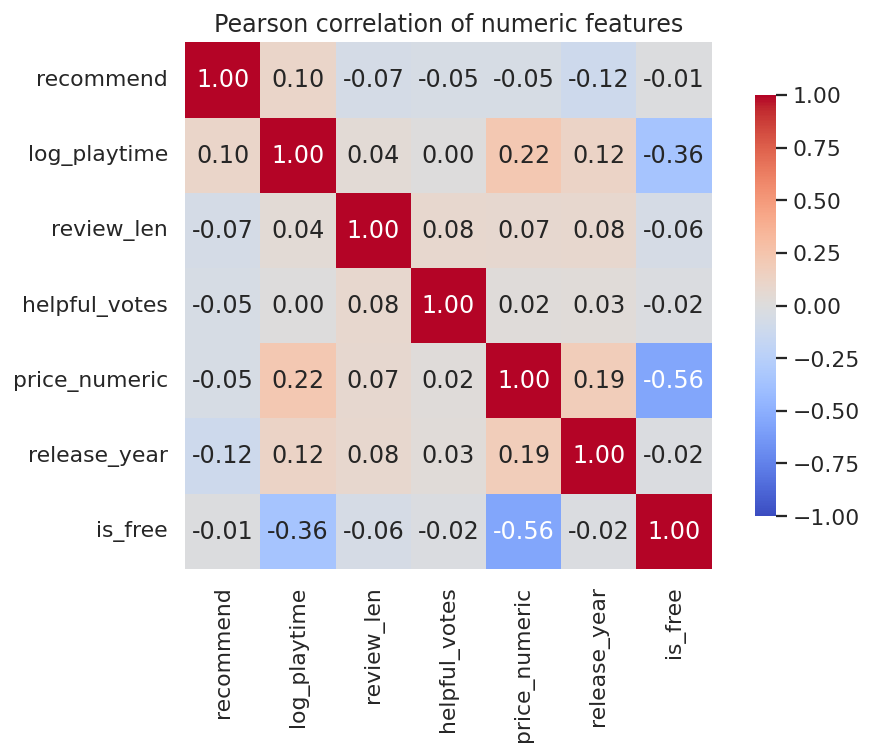

In [105]:
# Build a review-level table joining playtime and game metadata, then correlate numeric columns.
corr_df = (
    df_rev[["user_id", "item_id", "recommend", "review_len", "helpful_votes"]]
    .assign(recommend=lambda d: d["recommend"].astype(int))
    .merge(df_itm[["user_id", "item_id", "playtime_forever"]],
           on=["user_id", "item_id"], how="left")
    .merge(df_gm[["id", "price_numeric", "release_year", "is_free"]]
               .rename(columns={"id": "item_id"}),
           on="item_id", how="left")
)
corr_df["log_playtime"] = np.log1p(corr_df["playtime_forever"].fillna(0))
corr_df["is_free"]      = corr_df["is_free"].astype("Int64")

num_cols = ["recommend", "log_playtime", "review_len", "helpful_votes",
            "price_numeric", "release_year", "is_free"]
corr = corr_df[num_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson correlation of numeric features")
plt.tight_layout()
plt.show()

### EDA Summary

- **Target is skewed:** ~88% of reviews are positive, so we prefer ranking metrics (Hit@K, NDCG) over raw accuracy.
- **Very sparse matrix:** well below 1% dense on raw data; after filtering (users >= 5, items >= 10) we get a small dense core (~1.2K users x ~211 items).
- **Right-skewed numerics:** playtime, helpful votes, and review length all have long tails of legitimate power-user behaviour; we keep them but use `log1p` for playtime.
- **Cold-start is real:** many users and items have too few interactions to train on and get filtered out.
- **Playtime is the main continuous signal:** the only numeric feature with a meaningful correlation to `recommend`. Review length, helpful votes, and price are weak.
- **Game metadata will power item embeddings:** Indie, Action, and Casual dominate genres; tags are more fine-grained and richer. Release year and early-access flag can act as optional side features.

---
## 5. Data Preparation for Modeling

We convert the EDA-cleaned data into a format suitable for NeuMF training.

**Pipeline:**
1. Build a positive-only interaction table (`recommend=True`)
2. Iterative core filtering: users >= 5 reviews, items >= 10 reviews
3. Encode IDs to contiguous integers (required for `nn.Embedding`)
4. Build genre multi-hot matrix as side feature for the MLP branch
5. Leave-one-out temporal split: last interaction -> test, second-to-last -> val
6. Sample 4 negatives per positive each epoch

In [17]:
# -- 5. Data Preparation for Modeling ----------------------------------------
from project2.modeling.data_prep import (
    build_interaction_table, leave_one_out_split, sample_negatives
)

df_inter, user_to_idx, item_to_idx, idx_to_item, genre_matrix, genre_names = \
    build_interaction_table(df_rev, df_gm, min_user_reviews=5, min_item_reviews=10)

n_users  = len(user_to_idx)
n_items  = len(item_to_idx)
n_genres = genre_matrix.shape[1]

print("Interaction table after filtering:")
print(f"  Interactions : {len(df_inter):>7,}")
print(f"  Users        : {n_users:>7,}")
print(f"  Items        : {n_items:>7,}")
print(f"  Genres       : {n_genres:>7,}")
print(f"  Sparsity     : {1 - len(df_inter)/(n_users*n_items):.4%}")
print(f"\nGenre names ({n_genres}):", genre_names)


Interaction table after filtering:
  Interactions :   7,552
  Users        :   1,254
  Items        :     211
  Genres       :      22
  Sparsity     : 97.1458%

Genre names (22): ['Accounting', 'Action', 'Adventure', 'Animation &amp; Modeling', 'Audio Production', 'Casual', 'Design &amp; Illustration', 'Early Access', 'Education', 'Free to Play', 'Indie', 'Massively Multiplayer', 'Photo Editing', 'RPG', 'Racing', 'Simulation', 'Software Training', 'Sports', 'Strategy', 'Utilities', 'Video Production', 'Web Publishing']


In [18]:
# 5b. Leave-one-out temporal split
df_train, df_val, df_test = leave_one_out_split(df_inter)

print("Split sizes:")
print(f"  Train : {len(df_train):,} interactions  ({df_train['user_idx'].nunique():,} users)")
print(f"  Val   : {len(df_val):,} interactions  (1 per user, for early stopping)")
print(f"  Test  : {len(df_test):,} interactions  (1 per user, held-out evaluation)")


Split sizes:
  Train : 5,044 interactions  (1,254 users)
  Val   : 1,254 interactions  (1 per user, for early stopping)
  Test  : 1,254 interactions  (1 per user, held-out evaluation)


In [19]:
# 5c. Negative sampling preview
df_train_neg = sample_negatives(df_train, n_items, n_neg=4, seed=1)
pos = int(df_train_neg["label"].sum())
neg = len(df_train_neg) - pos
print(f"Training set with 4:1 negatives: {len(df_train_neg):,} rows")
print(f"  Positives : {pos:,}  (label=1)")
print(f"  Negatives : {neg:,}  (label=0,  ratio {neg//max(pos,1)}:1)")
print(f"\nGenre matrix shape: {genre_matrix.shape}  |  Non-zero entries: {int((genre_matrix>0).sum()):,}")


Training set with 4:1 negatives: 25,220 rows
  Positives : 5,044  (label=1)
  Negatives : 20,176  (label=0,  ratio 4:1)

Genre matrix shape: (211, 22)  |  Non-zero entries: 468


---
## 6. NeuMF Model Architecture

We implement **Neural Matrix Factorization** (He et al., 2017) with five variants for ablation:

| Variant | Description |
|---|---|
| **Popularity** | Non-personalised; score = item frequency in training set |
| **GMF-only** | Generalised MF: element-wise product of user x item embeddings |
| **MLP-only** | Multi-Layer Perceptron on concatenated embeddings |
| **NeuMF** | Fusion: GMF branch + MLP branch -> linear -> sigmoid |
| **NeuMF + genres** | Same NeuMF, MLP branch also receives genre multi-hot vectors |

**Why separate embeddings per branch?**
The GMF constrains interactions to be linear (element-wise product only).
If the MLP shared the same embeddings, its gradient updates would conflict with GMF's simpler
objective. Separate tables let each branch learn its own representation space.

In [20]:
# -- 6. Model definitions -----------------------------------------------------
import torch
from project2.modeling.model import PopularityBaseline, GMFOnly, MLPOnly, NeuMF

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GMF_EMB   = 32        # GMF branch embedding dim  (He et al. 2017)
MLP_EMB   = 64        # MLP branch embedding dim
MLP_DIMS  = (128, 64, 32)   # MLP hidden layer sizes
GENRE_DIM = 32        # genre projection dimension

print(f"Device: {DEVICE}")

# Parameter count
_m = NeuMF(n_users, n_items, gmf_emb_dim=GMF_EMB, mlp_emb_dim=MLP_EMB,
            n_genres=n_genres, genre_proj_dim=GENRE_DIM, hidden_dims=MLP_DIMS)
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"NeuMF + genres total parameters: {n_params:,}")
print()
print(_m)


Device: cpu
NeuMF + genres total parameters: 172,385

NeuMF(
  (gmf_user_emb): Embedding(1254, 32)
  (gmf_item_emb): Embedding(211, 32)
  (mlp_user_emb): Embedding(1254, 64)
  (mlp_item_emb): Embedding(211, 64)
  (genre_proj): Linear(in_features=22, out_features=32, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=160, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (fusion): Linear(in_features=64, out_features=1, bias=True)
)


---
## 7. Training & Iterative Justification

**Training setup:**
- Loss: Binary Cross-Entropy (BCE)
- Optimizer: Adam (lr=1e-3)
- Negative sampling: 4 negatives per positive, re-drawn each epoch
- Early stopping: patience=4 on validation NDCG@10
- Batch size: 512

**Iterative design decisions:**

| Decision | What we tried | Why |
|---|---|---|
| Interaction signal | recommend=True only | Binary feedback; negatives come from unobserved pairs |
| Filtering | >=5 reviews/user, >=10/item | Balance coverage vs density |
| Negative ratio | 4:1 | Standard in NCF literature |
| Early stopping | patience=4, NDCG@10 | Prevents overfitting; NDCG is the key ranking metric |
| Genre features | Multi-hot projected to 32 dims | Adds item content signal for cold-start |

In [21]:
# -- 7. Training --------------------------------------------------------------
from project2.modeling.train import train_model
from project2.modeling.evaluate import evaluate_all_k

TRAIN_KWARGS = dict(
    df_train     = df_train,
    df_val       = df_val,
    genre_matrix = genre_matrix,
    n_items      = n_items,
    n_neg        = 4,
    n_epochs     = 20,
    lr           = 1e-3,
    batch_size   = 512,
    patience     = 4,
    device       = DEVICE,
    k            = 10,
)

# Popularity baseline (no training needed)
item_counts = df_train["item_idx"].value_counts().to_dict()
pop_model   = PopularityBaseline(item_counts, n_items).to(DEVICE)
pop_metrics = evaluate_all_k(pop_model, df_train, df_test, genre_matrix, n_items,
                              DEVICE, k_values=(5, 10, 20))
print("Popularity baseline:", {k: round(v, 4) for k, v in pop_metrics.items()})


Popularity baseline: {'Hit@5': 0.1898, 'NDCG@5': 0.1231, 'Precision@5': 0.038, 'Hit@10': 0.2839, 'NDCG@10': 0.1537, 'Precision@10': 0.0284, 'Hit@20': 0.3541, 'NDCG@20': 0.1716, 'Precision@20': 0.0177}


In [22]:
# GMF-only
print("=== Training GMF-only ===")
gmf_model  = GMFOnly(n_users, n_items, emb_dim=GMF_EMB)
gmf_result = train_model(gmf_model, **TRAIN_KWARGS)


=== Training GMF-only ===
Epoch 01 | loss=0.7184 | Hit@10=0.0893 | NDCG@10=0.0467 | Precision@10=0.0089 | 3.5s
Epoch 02 | loss=0.7026 | Hit@10=0.3174 | NDCG@10=0.1798 | Precision@10=0.0317 | 1.6s
Epoch 03 | loss=0.6826 | Hit@10=0.3078 | NDCG@10=0.1778 | Precision@10=0.0308 | 4.7s
Epoch 04 | loss=0.6413 | Hit@10=0.3070 | NDCG@10=0.1775 | Precision@10=0.0307 | 4.9s
Epoch 05 | loss=0.5704 | Hit@10=0.3102 | NDCG@10=0.1789 | Precision@10=0.0310 | 1.2s
Epoch 06 | loss=0.4929 | Hit@10=0.3070 | NDCG@10=0.1775 | Precision@10=0.0307 | 1.4s
  -> Early stopping (no improvement for 4 epochs)


In [23]:
# MLP-only (no side features)
print("=== Training MLP-only (no genres) ===")
mlp_model  = MLPOnly(n_users, n_items, emb_dim=MLP_EMB, n_genres=0, hidden_dims=MLP_DIMS)
mlp_result = train_model(mlp_model, **TRAIN_KWARGS)


=== Training MLP-only (no genres) ===
Epoch 01 | loss=0.6403 | Hit@10=0.3046 | NDCG@10=0.1710 | Precision@10=0.0305 | 1.5s
Epoch 02 | loss=0.4275 | Hit@10=0.3086 | NDCG@10=0.1724 | Precision@10=0.0309 | 1.5s
Epoch 03 | loss=0.4109 | Hit@10=0.3006 | NDCG@10=0.1701 | Precision@10=0.0301 | 1.6s
Epoch 04 | loss=0.4045 | Hit@10=0.3062 | NDCG@10=0.1719 | Precision@10=0.0306 | 1.5s
Epoch 05 | loss=0.4023 | Hit@10=0.3078 | NDCG@10=0.1720 | Precision@10=0.0308 | 1.8s
Epoch 06 | loss=0.3995 | Hit@10=0.3070 | NDCG@10=0.1702 | Precision@10=0.0307 | 1.4s
  -> Early stopping (no improvement for 4 epochs)


In [24]:
# NeuMF (no side features)
print("=== Training NeuMF (no genres) ===")
neumf_model  = NeuMF(n_users, n_items, gmf_emb_dim=GMF_EMB, mlp_emb_dim=MLP_EMB,
                     n_genres=0, hidden_dims=MLP_DIMS)
neumf_result = train_model(neumf_model, **TRAIN_KWARGS)


=== Training NeuMF (no genres) ===
Epoch 01 | loss=0.5880 | Hit@10=0.3062 | NDCG@10=0.1705 | Precision@10=0.0306 | 1.8s
Epoch 02 | loss=0.4310 | Hit@10=0.3046 | NDCG@10=0.1705 | Precision@10=0.0305 | 1.7s
Epoch 03 | loss=0.4157 | Hit@10=0.3062 | NDCG@10=0.1705 | Precision@10=0.0306 | 1.8s
Epoch 04 | loss=0.4041 | Hit@10=0.3102 | NDCG@10=0.1719 | Precision@10=0.0310 | 1.7s
Epoch 05 | loss=0.3985 | Hit@10=0.3062 | NDCG@10=0.1717 | Precision@10=0.0306 | 1.9s
Epoch 06 | loss=0.3905 | Hit@10=0.3086 | NDCG@10=0.1725 | Precision@10=0.0309 | 1.5s
Epoch 07 | loss=0.3785 | Hit@10=0.2990 | NDCG@10=0.1741 | Precision@10=0.0299 | 1.6s
Epoch 08 | loss=0.3673 | Hit@10=0.2951 | NDCG@10=0.1727 | Precision@10=0.0295 | 1.7s
Epoch 09 | loss=0.3529 | Hit@10=0.3030 | NDCG@10=0.1746 | Precision@10=0.0303 | 1.6s
Epoch 10 | loss=0.3365 | Hit@10=0.2974 | NDCG@10=0.1707 | Precision@10=0.0297 | 2.0s
Epoch 11 | loss=0.3185 | Hit@10=0.2911 | NDCG@10=0.1692 | Precision@10=0.0291 | 1.7s
Epoch 12 | loss=0.2949 | Hit@1

In [25]:
# NeuMF + genre side features
print("=== Training NeuMF + genres ===")
neumf_g_model  = NeuMF(n_users, n_items, gmf_emb_dim=GMF_EMB, mlp_emb_dim=MLP_EMB,
                        n_genres=n_genres, genre_proj_dim=GENRE_DIM, hidden_dims=MLP_DIMS)
neumf_g_result = train_model(neumf_g_model, **TRAIN_KWARGS)


=== Training NeuMF + genres ===
Epoch 01 | loss=0.5780 | Hit@10=0.3062 | NDCG@10=0.1742 | Precision@10=0.0306 | 1.9s
Epoch 02 | loss=0.4248 | Hit@10=0.3110 | NDCG@10=0.1785 | Precision@10=0.0311 | 1.7s
Epoch 03 | loss=0.4162 | Hit@10=0.3054 | NDCG@10=0.1743 | Precision@10=0.0305 | 1.6s
Epoch 04 | loss=0.4075 | Hit@10=0.3110 | NDCG@10=0.1726 | Precision@10=0.0311 | 1.8s
Epoch 05 | loss=0.4010 | Hit@10=0.3014 | NDCG@10=0.1699 | Precision@10=0.0301 | 2.3s
Epoch 06 | loss=0.3914 | Hit@10=0.3086 | NDCG@10=0.1719 | Precision@10=0.0309 | 2.0s
  -> Early stopping (no improvement for 4 epochs)


---
## 8. Evaluation & Ablation Study

**Protocol:** Leave-one-out.  For each test user, rank all items not seen in training.
Check where the single held-out positive item lands.

**Metrics at K = 5, 10, 20:**
- **Hit@K** — is the test item in the top-K?
- **NDCG@K** — rewards higher-ranked correct items (discounted at log2(rank+1))
- **Precision@K** — fraction of top-K that is relevant (= Hit@K / K for leave-one-out)

In [26]:
# -- 8. Evaluation & Ablation Study -------------------------------------------
K_VALUES = (5, 10, 20)

def test_metrics(model, name):
    m = evaluate_all_k(model, df_train, df_test, genre_matrix, n_items,
                       DEVICE, k_values=K_VALUES)
    return {"Model": name, **{k: round(v, 4) for k, v in m.items()}}

ablation_rows = [
    test_metrics(pop_model,              "Popularity Baseline"),
    test_metrics(gmf_result["model"],    "GMF-only"),
    test_metrics(mlp_result["model"],    "MLP-only (no genres)"),
    test_metrics(neumf_result["model"],  "NeuMF (no genres)"),
    test_metrics(neumf_g_result["model"],"NeuMF + genres"),
]
ablation_df = pd.DataFrame(ablation_rows).set_index("Model")
display(ablation_df)


,Hit@5,NDCG@5,Precision@5,Hit@10,NDCG@10,Precision@10,Hit@20,NDCG@20,Precision@20
Model,,,,,,,,,
Popularity Baseline,0.1898,0.1231,0.0380,0.2839,0.1537,0.0284,0.3541,0.1716,0.0177
GMF-only,0.1922,0.1270,0.0384,0.2855,0.1571,0.0285,0.3676,0.1777,0.0184
MLP-only (no genres),0.2010,0.1287,0.0402,0.2871,0.1563,0.0287,0.3596,0.1746,0.0180
NeuMF (no genres),0.1882,0.1279,0.0376,0.2727,0.1556,0.0273,0.3557,0.1765,0.0178
NeuMF + genres,0.1834,0.1241,0.0367,0.2863,0.1576,0.0286,0.3596,0.1761,0.0180


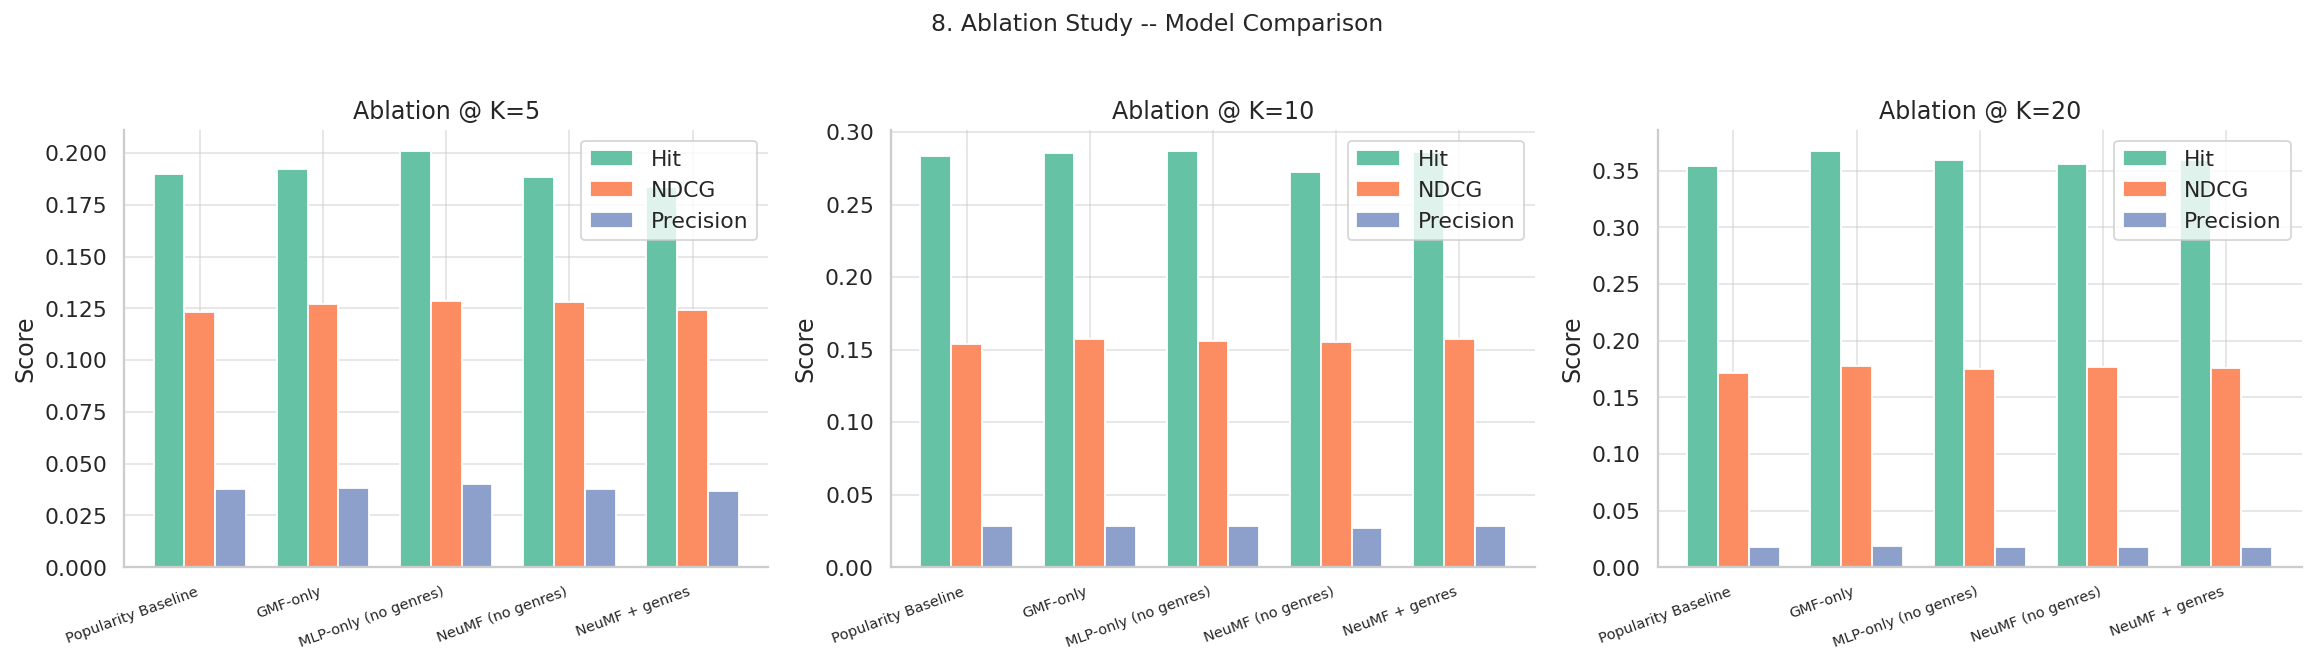

In [27]:
# 8b. Bar chart: all models x all metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = sns.color_palette("Set2", 3)

for ax, k in zip(axes, K_VALUES):
    cols   = [f"Hit@{k}", f"NDCG@{k}", f"Precision@{k}"]
    labels = ["Hit", "NDCG", "Precision"]
    models = ablation_df.index.tolist()
    x      = range(len(models))
    w      = 0.25
    for j, (col, lbl) in enumerate(zip(cols, labels)):
        ax.bar([xi + j*w for xi in x], ablation_df[col].values,
               width=w, label=lbl, color=colors[j], edgecolor="white")
    ax.set_xticks([xi + w for xi in x])
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=8)
    ax.set_title(f"Ablation @ K={k}")
    ax.set_ylabel("Score")
    ax.legend()

plt.suptitle("8. Ablation Study -- Model Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


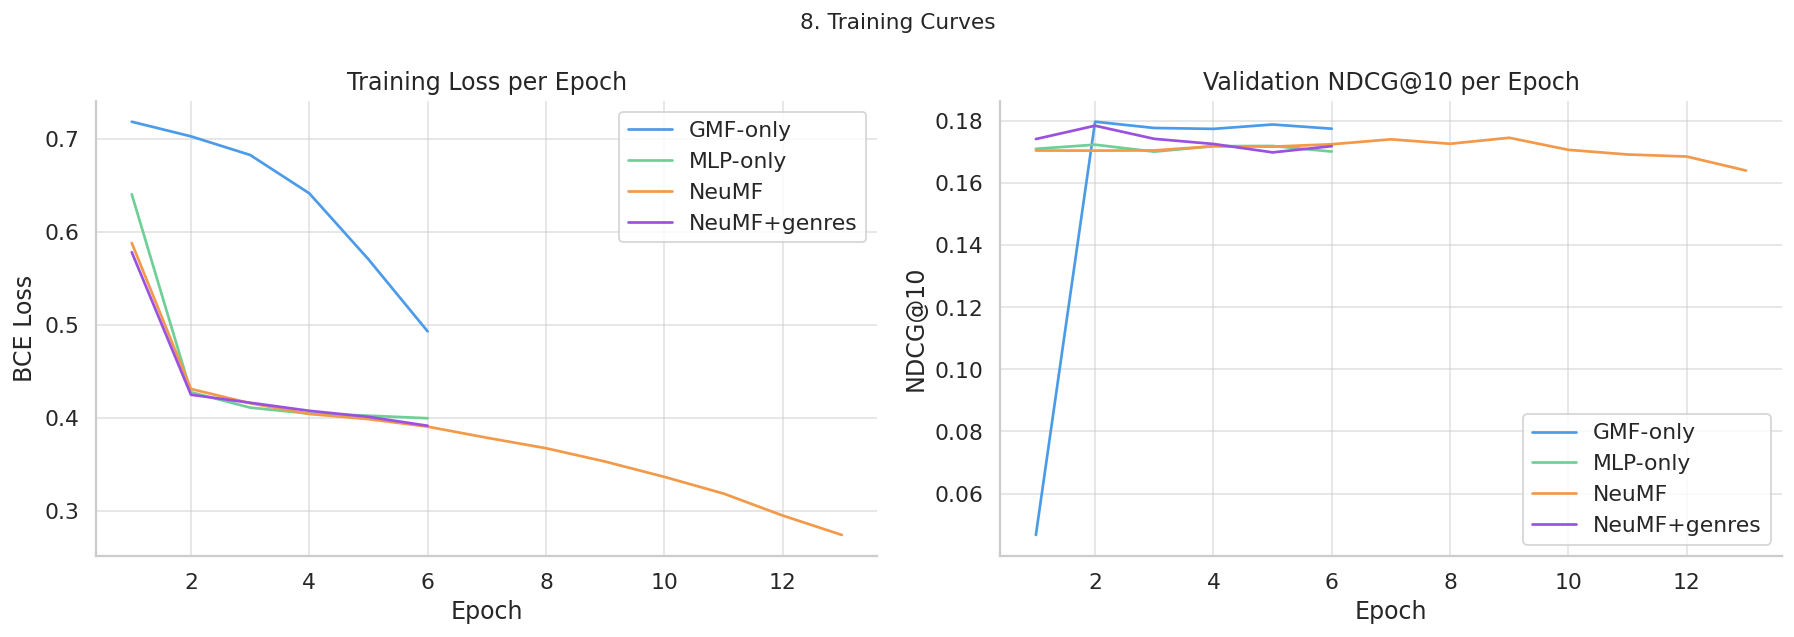

In [28]:
# 8c. Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {"GMF-only": "#4C9BE8", "MLP-only": "#6FCF97",
           "NeuMF": "#F2994A", "NeuMF+genres": "#9B51E0"}

for result, label in [
    (gmf_result,    "GMF-only"),
    (mlp_result,    "MLP-only"),
    (neumf_result,  "NeuMF"),
    (neumf_g_result,"NeuMF+genres"),
]:
    h = pd.DataFrame(result["history"])
    axes[0].plot(h["epoch"], h["loss"],       label=label, color=palette[label])
    axes[1].plot(h["epoch"], h["NDCG@10"],    label=label, color=palette[label])

axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss"); axes[0].legend()
axes[1].set_title("Validation NDCG@10 per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("NDCG@10"); axes[1].legend()
plt.suptitle("8. Training Curves", fontsize=12)
plt.tight_layout()
plt.show()


In [29]:
# 8d. Sample top-5 recommendations for 5 random users (NeuMF + genres)
import numpy as np

model_final = neumf_g_result["model"].eval().to(DEVICE)
genre_t     = torch.tensor(genre_matrix, dtype=torch.float32, device=DEVICE)
name_map    = df_gm.set_index("id")["app_name"].to_dict()

train_hist = {}
for u, i in zip(df_train["user_idx"], df_train["item_idx"]):
    train_hist.setdefault(int(u), set()).add(int(i))

rng = np.random.default_rng(99)
sample_users = rng.choice(list(train_hist.keys()), size=5, replace=False)

print(f"{'User idx':<10}  Top-5 Recommended Games")
print("-" * 80)
with torch.no_grad():
    for u in sample_users:
        seen    = train_hist[u]
        cands   = [i for i in range(n_items) if i not in seen]
        cands_t = torch.tensor(cands, dtype=torch.long, device=DEVICE)
        u_t     = torch.full((len(cands),), u, dtype=torch.long, device=DEVICE)
        scores  = model_final(u_t, cands_t, genre_t[cands_t]).cpu().numpy()
        top5    = np.array(cands)[np.argsort(-scores)[:5]]
        top5_names = [name_map.get(idx_to_item.get(i, ""), f"item_{i}") for i in top5]
        print(f"  user_{u:<6} {top5_names}")


User idx    Top-5 Recommended Games
--------------------------------------------------------------------------------
  user_1197   ['Counter-Strike: Global Offensive', "Garry's Mod", 'Left 4 Dead 2', 'Unturned', 'Terraria']
  user_633    ['Team Fortress 2', 'Counter-Strike: Global Offensive', "Garry's Mod", 'Left 4 Dead 2', 'Unturned']
  user_222    ['Team Fortress 2', 'Counter-Strike: Global Offensive', "Garry's Mod", 'Left 4 Dead 2', 'Unturned']
  user_708    ['Team Fortress 2', 'Counter-Strike: Global Offensive', "Garry's Mod", 'Unturned', 'Terraria']
  user_948    ['Counter-Strike: Global Offensive', "Garry's Mod", 'Left 4 Dead 2', 'Unturned', 'Terraria']
